---

## Run one trial

Edit the parameters below and re-run this cell. Everything above should already be loaded in the kernel.

**Valid field types:** `'double_vortex'`, `'double_saddle'`, `'double_gyre'`
**Valid logics:** `'A'`, `'B'`, `'C'`, `'D'`, `'E'`, `'F'`

Reasonable starting positions:
- `double_vortex` (domain roughly [-5, 5]²): try `(-0.5, -3.4)` or `(2.5, 3.0)`.
- `double_saddle` (domain roughly [-6, 6]²): try `(-2.02, -2.5)` or `(1.5, -1.0)`.
- `double_gyre` (domain `[0,2] × [0,1]`): try `(0.3, 0.3)`, `(1.5, 0.7)`, or `(0.8, 0.5)`.

Note on `correction_weight`:
- For A/B/C it's the weight of the orthogonal ∇det(J) correction added to the primary eigenvector.
- For D/E/F it's the blend weight: when the cosine check is positive, the step is `(1 - w)·descent + w·reference`.
- Default 0.5 works for both interpretations.

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg
from scipy.integrate import solve_ivp
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')


## Vector field

In [194]:
class VectorField:
    """Four field types: 'double_vortex', 'double_saddle', 'double_gyre', 'four_vortex'."""

    def __init__(self, field_type='double_vortex',
                 dg_A=0.1, dg_eps=0.0, dg_omega=2*np.pi/10, dg_t=0.0):
        self.field_type = field_type
        self.vortex1_pos = np.array([-2, -1])
        self.vortex2_pos = np.array([2, -1])
        self.saddle1_pos = np.array([3, 3])
        self.saddle2_pos = np.array([-3, -3])
        # Four-vortex field parameters
        self.fv_centers = np.array([[-1,3],[1,3],[-1,-1],[1,-1]], dtype=float)
        self.fv_signs   = [1, -1, -1, 1]
        # Double-gyre parameters (Shadden-Lekien-Marsden 2005)
        self.dg_A = dg_A
        self.dg_eps = dg_eps
        self.dg_omega = dg_omega
        self.dg_t = dg_t

    def evaluate(self, x, y):
        if self.field_type == 'double_vortex':
            x1, y1 = self.vortex1_pos
            vx1 = -(y - y1); vy1 = (x - x1)
            x2, y2 = self.vortex2_pos
            vx2 =  (y - y2); vy2 = -(x - x2)
            d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
            d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
            w1 = 1.0 / (d1**2 + 0.1)
            w2 = 1.0 / (d2**2 + 0.1)
            vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
            vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
            return np.array([10*vx, 10*vy])

        elif self.field_type == 'double_saddle':
            s1 = self.saddle1_pos; s2 = self.saddle2_pos
            rot1, rot2 = np.pi/4, -np.pi/4

            x1c = x - s1[0]; y1c = y - s1[1]
            c1, si1 = np.cos(rot1), np.sin(rot1)
            x1r = c1*x1c - si1*y1c; y1r = si1*x1c + c1*y1c
            u1r =  x1r; v1r = -y1r
            u1 =  c1*u1r + si1*v1r
            v1 = -si1*u1r +  c1*v1r

            x2c = x - s2[0]; y2c = y - s2[1]
            c2, si2 = np.cos(rot2), np.sin(rot2)
            x2r = c2*x2c - si2*y2c; y2r = si2*x2c + c2*y2c
            u2r =  x2r; v2r = -y2r
            u2 =  c2*u2r + si2*v2r
            v2 = -si2*u2r +  c2*v2r

            d1 = np.sqrt((x - s1[0])**2 + (y - s1[1])**2) + 0.01
            d2 = np.sqrt((x - s2[0])**2 + (y - s2[1])**2) + 0.01
            w1 = 1.0 / (d1**2); w2 = 1.0 / (d2**2)
            tw = w1 + w2
            return np.array([(u1*w1 + u2*w2)/tw, (v1*w1 + v2*w2)/tw])

        elif self.field_type == 'double_gyre':
            # Shadden-Lekien-Marsden 2005 double gyre on [0,2] x [0,1]
            A = self.dg_A; eps = self.dg_eps
            omega = self.dg_omega; t = self.dg_t
            f  = eps * np.sin(omega*t) * x**2 + (1 - 2*eps*np.sin(omega*t)) * x
            df = 2*eps * np.sin(omega*t) * x + (1 - 2*eps*np.sin(omega*t))
            u = -np.pi * A * np.sin(np.pi*f) * np.cos(np.pi*y)
            v =  np.pi * A * np.cos(np.pi*f) * np.sin(np.pi*y) * df
            return np.array([u, v])

        elif self.field_type == 'four_vortex':
            eps = 0.1
            vx, vy = 0.0, 0.0
            for (cx, cy), sign in zip(self.fv_centers, self.fv_signs):
                dx, dy = x - cx, y - cy
                r2 = dx**2 + dy**2 + eps
                vx += -sign * dy / r2
                vy +=  sign * dx / r2
            return np.array([vx, vy])

        else:
            raise ValueError(f"Unknown field_type: {self.field_type}")

    def jacobian_twosided(self, x, y, h=0.01):
        fxp, fyp = self.evaluate(x + h, y)
        fxm, fym = self.evaluate(x - h, y)
        fxyp, fyyp = self.evaluate(x, y + h)
        fxym, fyym = self.evaluate(x, y - h)
        return np.array([
            [(fxp - fxm)/(2*h), (fxyp - fxym)/(2*h)],
            [(fyp - fym)/(2*h), (fyyp - fyym)/(2*h)],
        ])

## Four-robot cluster

In [195]:
class RobotCluster4:
    """Four robots in a square, with 4-choose-3 gradient estimation of det(J)."""

    def __init__(self, formation_radius=0.3, initial_pos=(0.0, 0.0),
                 init_mode=2, manual_offset=0.0, seed=None):
        rng = np.random.default_rng(seed)
        self.formation_radius = formation_radius
        self.init_mode = init_mode
        self.centroid = np.array(initial_pos, dtype=float)
        self.positions = np.zeros((4, 2))
        self.vector_readings = np.zeros((4, 2))

        if init_mode == 1:
            self.formation_angle = manual_offset + np.pi/4
            self.rotation_enabled = False
        else:
            self.formation_angle = rng.uniform(0, 2*np.pi)
            self.rotation_enabled = True

        self.angle_history = [self.formation_angle]
        self._update_robot_positions()

    def _update_robot_positions(self):
        angles = np.linspace(0, 2*np.pi, 4, endpoint=False) + self.formation_angle
        for i in range(4):
            self.positions[i] = self.centroid + self.formation_radius * np.array(
                [np.cos(angles[i]), np.sin(angles[i])]
            )

    def update_readings(self, vector_field):
        for i in range(4):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)

    def compute_jacobian(self):
        A = np.column_stack([self.positions[:, 0], self.positions[:, 1], np.ones(4)])
        b_u = self.vector_readings[:, 0]; b_v = self.vector_readings[:, 1]
        try:
            cu, *_ = np.linalg.lstsq(A, b_u, rcond=None)
            cv, *_ = np.linalg.lstsq(A, b_v, rcond=None)
            return np.array([[cu[0], cu[1]], [cv[0], cv[1]]])
        except np.linalg.LinAlgError:
            return None

    def compute_determinant_gradient(self):
        """Plane-fit ∇det(J) from four 3-robot sub-formations."""
        J_current = self.compute_jacobian()
        if J_current is None:
            return np.array([0.0, 0.0])
        det_current = np.linalg.det(J_current)

        dets, cents = [], []
        for combo in combinations(range(4), 3):
            pos_s = self.positions[list(combo)]
            read_s = self.vector_readings[list(combo)]
            centroid = np.mean(pos_s, axis=0)
            A = np.column_stack([pos_s[:, 0], pos_s[:, 1], np.ones(3)])
            try:
                cu, _, _, s_u = np.linalg.lstsq(A, read_s[:, 0], rcond=None)
                cv, _, _, _   = np.linalg.lstsq(A, read_s[:, 1], rcond=None)
                if len(s_u) > 0 and s_u[-1] > 1e-12:
                    cond = s_u[0] / s_u[-1]
                    if cond > 1e8:
                        continue
                J = np.array([[cu[0], cu[1]], [cv[0], cv[1]]])
                dets.append(np.linalg.det(J)); cents.append(centroid)
            except np.linalg.LinAlgError:
                continue

        if len(cents) < 4:
            return np.array([0.0, 0.0])
        cents = np.array(cents); dets = np.array(dets)
        Ag = np.column_stack([cents[:, 0], cents[:, 1], np.ones(len(cents))])
        try:
            c, *_ = np.linalg.lstsq(Ag, dets, rcond=None)
            grad = np.array([c[0], c[1]])
            if np.linalg.norm(grad) > 1e-10:
                return -np.sign(det_current) * grad / np.linalg.norm(grad)
            return np.array([0.0, 0.0])
        except np.linalg.LinAlgError:
            return np.array([0.0, 0.0])

    def update_formation_orientation(self, target_direction, adaptation_rate=0.15):
        if not self.rotation_enabled:
            return
        tracking_angle = self.formation_angle - np.pi/4
        target_angle = np.arctan2(target_direction[1], target_direction[0])
        diff = target_angle - tracking_angle
        while diff >  np.pi: diff -= 2*np.pi
        while diff < -np.pi: diff += 2*np.pi
        self.formation_angle = (self.formation_angle + adaptation_rate * diff) % (2*np.pi)
        self.angle_history.append(self.formation_angle)
        self._update_robot_positions()

    def update_positions(self, delta):
        self.centroid = self.centroid + delta
        self._update_robot_positions()


## Three control logics

Each function returns a unit-norm primary direction. Flipping against the flow is handled identically in all three.

- **A — Flow-aligned.** Pick the eigenvector most aligned with the local flow.
- **B — Most-negative eigenvalue.** Pick the eigenvector with the most negative real eigenvalue.
- **C — Sigmoid blend.** Interpolate between A and B based on det(J).

In [196]:
def _normalise(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-12 else v

def _consistent_with_flow(direction, flow_norm):
    return direction if np.dot(direction, flow_norm) >= 0 else -direction


def logic_A_flow_aligned(J, flow):
    flow_n = _normalise(flow)
    evals, evecs = np.linalg.eig(J)
    e1 = _normalise(np.real(evecs[:, 0]))
    e2 = _normalise(np.real(evecs[:, 1]))
    primary = e1 if abs(np.dot(flow_n, e1)) > abs(np.dot(flow_n, e2)) else e2
    return _consistent_with_flow(primary, flow_n)


def logic_B_most_negative(J, flow):
    flow_n = _normalise(flow)
    evals, evecs = np.linalg.eig(J)
    e1 = _normalise(np.real(evecs[:, 0]))
    e2 = _normalise(np.real(evecs[:, 1]))
    primary = e1 if np.real(evals[0]) < np.real(evals[1]) else e2
    return _consistent_with_flow(primary, flow_n)


def logic_C_blended(J, flow, det_J, blend_center=5.0, blend_steepness=2.0):
    flow_n = _normalise(flow)
    evals, evecs = np.linalg.eig(J)
    e1 = _normalise(np.real(evecs[:, 0]))
    e2 = _normalise(np.real(evecs[:, 1]))

    w = 0.5 * (1 + np.tanh((det_J - blend_center) / blend_steepness))

    eigval_score1 = np.exp(-max(0, np.real(evals[0])))
    eigval_score2 = np.exp(-max(0, np.real(evals[1])))
    flow_score1   = abs(np.dot(flow_n, e1))
    flow_score2   = abs(np.dot(flow_n, e2))

    s1 = (1 - w) * eigval_score1 + w * flow_score1
    s2 = (1 - w) * eigval_score2 + w * flow_score2

    primary = e1 if s1 > s2 else e2
    return _consistent_with_flow(primary, flow_n)


# ------------------------------------------------------------------------
# Logic D: sign-flipped descent as primary, flow as reference
# ------------------------------------------------------------------------
def _signed_descent(det_J, grad_det):
    """-sign(det(J)) * grad_det / |grad_det|. None if gradient too small."""
    n = np.linalg.norm(grad_det)
    if n < 1e-10:
        return None
    return -np.sign(det_J) * grad_det / n


def _perp_aligned_with(direction, reference):
    """Of the two perpendiculars to `direction`, return the unit one whose
    dot product with `reference` is larger."""
    p_plus  = np.array([-direction[1],  direction[0]])
    p_minus = np.array([ direction[1], -direction[0]])
    if np.dot(p_plus, reference) >= np.dot(p_minus, reference):
        return p_plus / (np.linalg.norm(p_plus) + 1e-12)
    else:
        return p_minus / (np.linalg.norm(p_minus) + 1e-12)


def logic_D_descent_flow(J, flow, det_J, grad_det, correction_weight=0.5):
    """D (clean rebuild): steepest-decrease direction of det(J) as primary.

    Step 1: direction of steepest DECREASE of det(J) is -grad(det(J)), unit-normalised.
            This is the direction toward more-negative det(J), regardless of current
            sign of det(J).  No sign flip based on det(J)'s sign.
    Step 2: cosine similarity between Step-1 direction and the UNIT mean flow.
    Step 3a (positive cosine): blend
                direction = (1 - w) * descent + w * flow_unit,
            where w = correction_weight.  Then normalise.
    Step 3b (negative cosine): primary = perpendicular of descent most aligned with
            flow.  No blend with descent.  The flow is implicitly the correction
            (we pick the perpendicular whose dot product with flow is larger).

    Returns (unit_direction, used_perpendicular_branch: bool).
    """
    n = np.linalg.norm(grad_det)
    if n < 1e-10:
        # Nothing to descend on; fall back to flow
        return _normalise(flow), False

    descent = -grad_det / n  # direction toward MORE NEGATIVE det(J)
    flow_unit = _normalise(flow)
    cos_sim = np.dot(descent, flow_unit)

    if cos_sim >= 0:
        # Positive branch: blend descent and flow by correction_weight
        blend = (1 - correction_weight) * descent + correction_weight * flow_unit
        return _normalise(blend), False
    else:
        # Negative branch: pick perpendicular of descent most aligned with flow
        return _perp_aligned_with(descent, flow_unit), True


def logic_E_descent_eigenvec(J, flow, det_J, grad_det, correction_weight=0.5):
    """E (clean rebuild, parallel to D): steepest-decrease direction of det(J)
    as primary; reference = flow-aligned most-negative-eigenvalue eigenvector.

    Step 1: direction of steepest DECREASE of det(J) is -grad(det(J)), unit-normalised.
            Same as D.
    Step 2: reference direction = eigenvector of J with the most-negative real
            eigenvalue, sign-flipped so that it agrees with the local flow
            (dot(ref, flow) >= 0).  If eigenvalues are tied or complex-conjugate,
            either eigenvector choice is acceptable; the flow-alignment step
            removes sign ambiguity.
    Step 3: cosine similarity between Step-1 direction and the unit reference.
    Step 4a (positive cosine): blend
                direction = (1 - w) * descent + w * ref,
            where w = correction_weight.  Then normalise.
    Step 4b (negative cosine): primary = perpendicular of descent most aligned
            with the reference.  No blend with descent.

    Returns (unit_direction, used_perpendicular_branch: bool).
    """
    n = np.linalg.norm(grad_det)
    if n < 1e-10:
        return _normalise(flow), False

    descent = -grad_det / n  # direction toward MORE NEGATIVE det(J)

    # Build the reference: most-negative-eigenvalue eigenvector, sign-aligned with flow
    evals, evecs = np.linalg.eig(J)
    k = int(np.argmin(np.real(evals)))
    ref = _normalise(np.real(evecs[:, k]))
    if np.dot(ref, flow) < 0:
        ref = -ref

    cos_sim = np.dot(descent, ref)

    if cos_sim >= 0:
        blend = (1 - correction_weight) * descent + correction_weight * ref
        return _normalise(blend), False
    else:
        return _perp_aligned_with(descent, ref), True


def logic_F_blended_DE(J, flow, det_J, grad_det, correction_weight=0.5,
                       blend_center=5.0, blend_steepness=2.0):
    """F: sigmoid blend of D and E, weighted by det(J).

    At large det(J) the weight tips toward D (flow reference). At small det(J)
    the weight tips toward E (eigenvector reference). Same sigmoid shape as C.
    """
    d_dir, _ = logic_D_descent_flow(J, flow, det_J, grad_det, correction_weight)
    e_dir, _ = logic_E_descent_eigenvec(J, flow, det_J, grad_det, correction_weight)

    w = 0.5 * (1 + np.tanh((det_J - blend_center) / blend_steepness))
    # w ~ 1 at large det(J)  -> use D
    # w ~ 0 at small det(J)  -> use E
    blended = w * d_dir + (1 - w) * e_dir
    return _normalise(blended), False


# Logic G: Newton-blend (from interactive5)
def logic_G_newton_blend(J, flow, det_J, blend_factor=0.5):
    """G: Newton-blend — perpendicular to critical direction, blended with flow."""
    flow_unit = _normalise(flow)
    if abs(det_J) > 0.01:
        try:
            J_inv = np.linalg.inv(J)
            crit = J_inv @ flow
            perp = np.array([-crit[1], crit[0]])
            if np.dot(perp, flow) < 0:
                perp = -perp
            perp = _normalise(perp)
            return _normalise(blend_factor * flow_unit + (1 - blend_factor) * perp)
        except np.linalg.LinAlgError:
            pass
    return flow_unit


# Logic H: Newton-like (from interactive5)
def logic_H_newton_like(J, flow, det_J, newton_weight=0.1):
    """H: Newton-like — blend flow with Newton direction toward fixed point."""
    flow_unit = _normalise(flow)
    if abs(det_J) > 0.01:
        try:
            J_inv = np.linalg.inv(J)
            return _normalise(flow_unit + newton_weight * (-J_inv @ flow))
        except np.linalg.LinAlgError:
            pass
    return flow_unit


# Logic I: Condition-number blending (from interactive6 concept)
def logic_I_condition_blend(J, flow, correction, correction_weight=0.5,
                             cond_center=5.0, cond_steepness=1.0):
    """I: Condition-number adaptive blending — trust flow when J is ill-conditioned."""
    flow_unit = _normalise(flow)
    primary = logic_A_flow_aligned(J, flow)
    corr_parallel = np.dot(correction, primary) * primary
    corr_orthog   = correction - corr_parallel
    eigvec_dir = _normalise(primary + correction_weight * corr_orthog)
    cond_J = np.linalg.cond(J)
    free_ratio = 1.0 / (1.0 + np.exp(-(cond_J - cond_center) / cond_steepness))
    return _normalise((1 - free_ratio) * eigvec_dir + free_ratio * flow_unit)

In [197]:
import numpy as np


def _normalise(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-12 else v


def _perp_aligned_with(direction, reference):
    """Of the two perpendiculars to `direction`, return the unit one whose
    dot product with `reference` is larger."""
    p_plus  = np.array([-direction[1],  direction[0]])
    p_minus = np.array([ direction[1], -direction[0]])
    if np.dot(p_plus, reference) >= np.dot(p_minus, reference):
        return p_plus / (np.linalg.norm(p_plus) + 1e-12)
    else:
        return p_minus / (np.linalg.norm(p_minus) + 1e-12)


def _zero_seeking_descent(det_J, grad_det):
    """Direction that pushes det(J) toward zero.

    -sign(det(J)) * grad(det) / |grad(det)|

    When det(J) > 0 this descends (pushes det negative, i.e. toward zero).
    When det(J) < 0 this ascends (pushes det positive, i.e. toward zero).
    Returns None if gradient is too small.
    """
    n = np.linalg.norm(grad_det)
    if n < 1e-10:
        return None
    return -np.sign(det_J) * grad_det / n


# ------------------------------------------------------------------------
# G: sign-flipped descent toward det(J)=0, flow as reference
#    (mirrors D structurally)
# ------------------------------------------------------------------------
def logic_G_zero_flow(J, flow, det_J, grad_det, correction_weight=0.5):
    """G: direction toward det(J)=0 as primary; flow as reference.

    Step 1: direction = -sign(det(J)) * grad(det(J)) / |grad(det(J))|.
            This pushes det(J) toward zero from whichever side it's on.
    Step 2: cosine similarity between Step-1 direction and the unit flow.
    Step 3a (positive cosine): blend
                direction = (1 - w) * zero_dir + w * flow_unit,
            where w = correction_weight.  Then normalise.
    Step 3b (negative cosine): primary = perpendicular of zero_dir most
            aligned with flow.

    Returns (unit_direction, used_perpendicular_branch: bool).
    """
    zero_dir = _zero_seeking_descent(det_J, grad_det)
    if zero_dir is None:
        return _normalise(flow), False

    flow_unit = _normalise(flow)
    cos_sim = np.dot(zero_dir, flow_unit)

    if cos_sim >= 0:
        blend = (1 - correction_weight) * zero_dir + correction_weight * flow_unit
        return _normalise(blend), False
    else:
        return _perp_aligned_with(zero_dir, flow_unit), True


# ------------------------------------------------------------------------
# H: sign-flipped descent toward det(J)=0, eigenvector as reference
#    (mirrors E structurally)
# ------------------------------------------------------------------------
def logic_H_zero_eigenvec(J, flow, det_J, grad_det, correction_weight=0.5):
    """H: direction toward det(J)=0 as primary; flow-aligned most-negative-
    eigenvalue eigenvector as reference.

    Step 1: direction = -sign(det(J)) * grad(det(J)) / |grad(det(J))|.
            Same as G.
    Step 2: reference = eigenvector of J with the most-negative real
            eigenvalue, sign-flipped so dot(ref, flow) >= 0.
    Step 3: cosine similarity between Step-1 direction and the reference.
    Step 4a (positive cosine): blend
                direction = (1 - w) * zero_dir + w * ref,
            where w = correction_weight.  Then normalise.
    Step 4b (negative cosine): primary = perpendicular of zero_dir most
            aligned with reference.

    Returns (unit_direction, used_perpendicular_branch: bool).
    """
    zero_dir = _zero_seeking_descent(det_J, grad_det)
    if zero_dir is None:
        return _normalise(flow), False

    # Build reference: most-negative-eigenvalue eigenvector, sign-aligned with flow
    evals, evecs = np.linalg.eig(J)
    k = int(np.argmin(np.real(evals)))
    ref = _normalise(np.real(evecs[:, k]))
    if np.dot(ref, flow) < 0:
        ref = -ref

    cos_sim = np.dot(zero_dir, ref)

    if cos_sim >= 0:
        blend = (1 - correction_weight) * zero_dir + correction_weight * ref
        return _normalise(blend), False
    else:
        return _perp_aligned_with(zero_dir, ref), True


# ------------------------------------------------------------------------
# I: sigmoid blend of G and H, weighted by det(J)
#    (mirrors F structurally)
# ------------------------------------------------------------------------
def logic_I_blended_GH(J, flow, det_J, grad_det, correction_weight=0.5,
                       blend_center=5.0, blend_steepness=2.0):
    """I: sigmoid blend of G and H, weighted by det(J).

    At large det(J) the weight tips toward G (flow reference).
    At small det(J) the weight tips toward H (eigenvector reference).
    Same sigmoid shape as F.
    """
    g_dir, _ = logic_G_zero_flow(J, flow, det_J, grad_det, correction_weight)
    h_dir, _ = logic_H_zero_eigenvec(J, flow, det_J, grad_det, correction_weight)

    w = 0.5 * (1 + np.tanh((det_J - blend_center) / blend_steepness))
    # w ~ 1 at large det(J)  -> use G (flow reference)
    # w ~ 0 at small det(J)  -> use H (eigenvector reference)
    blended = w * g_dir + (1 - w) * h_dir
    return _normalise(blended), False

## Simulation driver

In [198]:
def simulate(field_type, logic, initial_pos,
             n_steps=300, step_size=0.02,
             rotation_rate=0.15, correction_weight=0.5,
             formation_radius=0.3, init_mode=2, manual_offset=0.0,
             seed=None):
    """One trial. Returns (centroid_history, eigvec_history, robots, vector_field)."""
    vf = VectorField(field_type=field_type)
    robots = RobotCluster4(formation_radius=formation_radius,
                           initial_pos=initial_pos,
                           init_mode=init_mode,
                           manual_offset=manual_offset,
                           seed=seed)

    centroid_hist = np.zeros((n_steps, 2))
    eigvec_hist = []

    for step in range(n_steps):
        centroid_hist[step] = robots.centroid
        robots.update_readings(vf)

        correction = robots.compute_determinant_gradient()
        J = robots.compute_jacobian()
        if J is None:
            continue

        det_J = np.linalg.det(J)
        flow = np.mean(robots.vector_readings, axis=0)

        if logic == 'A':
            primary = logic_A_flow_aligned(J, flow)
        elif logic == 'B':
            primary = logic_B_most_negative(J, flow)
        elif logic == 'C':
            primary = logic_C_blended(J, flow, det_J)
        else:
            raise ValueError(f"Unknown logic: {logic}")

        robots.update_formation_orientation(primary, rotation_rate)

        corr_parallel = np.dot(correction, primary) * primary
        corr_orthog   = correction - corr_parallel
        direction = primary + correction_weight * corr_orthog
        direction = _normalise(direction)

        robots.update_positions(step_size * direction)
        eigvec_hist.append((robots.centroid.copy(), primary.copy()))

    return centroid_hist, eigvec_hist, robots, vf


## Analytical overlays

Used by the plotting function so you can visually judge how close the cluster got to the true structure.
- `double_vortex`: the dividing streamline is exactly `x = 0` (symmetry argument).
- `double_saddle`: integrate stable and unstable manifolds from each saddle's eigenvectors.

In [199]:
def compute_saddle_manifolds(vf, t_max=20.0, offset=0.01, rtol=1e-8, max_step=0.005):
    """Integrate stable/unstable manifolds from each saddle's eigenvectors.

    Works for 'double_saddle' (uses vf.saddle1_pos, vf.saddle2_pos) and
    'double_gyre' (corner saddles at (1,0) and (1,1))."""
    def flow(t, s): return vf.evaluate(s[0], s[1])
    def flow_back(t, s): return -vf.evaluate(s[0], s[1])

    if vf.field_type == 'double_saddle':
        saddles = [vf.saddle1_pos, vf.saddle2_pos]
    elif vf.field_type == 'double_gyre':
        saddles = [np.array([1.0, 0.0]), np.array([1.0, 1.0])]
    else:
        return {'stable': [], 'unstable': []}

    manifolds = {'stable': [], 'unstable': []}
    for saddle in saddles:
        J = vf.jacobian_twosided(saddle[0], saddle[1])
        evals, evecs = np.linalg.eig(J)
        for k in range(2):
            v = _normalise(np.real(evecs[:, k]))
            for sign in (+1, -1):
                start = saddle + sign * offset * v
                if np.real(evals[k]) > 0:
                    sol = solve_ivp(flow, [0, t_max], start, rtol=rtol, max_step=max_step)
                    manifolds['unstable'].append(sol.y)
                else:
                    sol = solve_ivp(flow_back, [0, t_max], start, rtol=rtol, max_step=max_step)
                    manifolds['stable'].append(sol.y)
    return manifolds

## Result plot

In [200]:
def plot_trial(centroid_hist, eigvec_hist, robots, vf, title=''):
    fig, ax = plt.subplots(figsize=(9, 9))

    if vf.field_type == 'double_vortex':
        xlim, ylim = (-5, 5), (-5, 5)
    elif vf.field_type == 'double_saddle':
        xlim, ylim = (-6, 6), (-6, 6)
    elif vf.field_type == 'double_gyre':
        xlim, ylim = (0, 2), (0, 1)
    elif vf.field_type == 'four_vortex':
        xlim, ylim = (-3, 3), (-2, 5)
    else:
        xlim, ylim = (-5, 5), (-5, 5)

    # Background quiver
    xg = np.linspace(xlim[0], xlim[1], 22)
    yg = np.linspace(ylim[0], ylim[1], 22)
    X, Y = np.meshgrid(xg, yg)
    U = np.zeros_like(X); V = np.zeros_like(Y)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
    mag = np.sqrt(U**2 + V**2) + 1e-6
    ax.quiver(X, Y, U/mag, V/mag, alpha=0.25, color='gray')

    # Analytical overlay
    if vf.field_type == 'double_vortex':
        ax.axvline(0, color='red', linestyle='--', linewidth=2,
                   label='Analytical dividing streamline (x=0)')
        ax.scatter(*vf.vortex1_pos, c='black', s=80, zorder=5)
        ax.scatter(*vf.vortex2_pos, c='black', s=80, zorder=5)

    elif vf.field_type == 'double_saddle':
        mf = compute_saddle_manifolds(vf)
        for k, curve in enumerate(mf['unstable']):
            ax.plot(curve[0], curve[1], 'b-', lw=2, alpha=0.8,
                    label='Unstable manifold' if k == 0 else None)
        for k, curve in enumerate(mf['stable']):
            ax.plot(curve[0], curve[1], 'g-', lw=2, alpha=0.8,
                    label='Stable manifold' if k == 0 else None)
        ax.scatter(*vf.saddle1_pos, c='red', s=120, marker='o', zorder=5, label='Saddle')
        ax.scatter(*vf.saddle2_pos, c='red', s=120, marker='o', zorder=5)

    elif vf.field_type == 'double_gyre':
        # Classical separatrix = cell boundary at x = 1 (for steady case)
        ax.axvline(1.0, color='red', linestyle='--', linewidth=2,
                   label='Classical separatrix (x = 1)')
        # det(J) = 0 contour — the Okubo-Weiss boundary (what our method tracks)
        res = 150
        xs_g = np.linspace(0.001, 1.999, res)
        ys_g = np.linspace(0.001, 0.999, res)
        Xg, Yg = np.meshgrid(xs_g, ys_g)
        Dg = np.zeros_like(Xg)
        for i in range(res):
            for j in range(res):
                Dg[i, j] = np.linalg.det(vf.jacobian_twosided(Xg[i, j], Yg[i, j]))
        ax.contour(Xg, Yg, Dg, levels=[0], colors='purple', linewidths=2,
                   linestyles='-')
        # Dummy entry for the legend
        ax.plot([], [], color='purple', lw=2, label='det(J) = 0 contour')
        # Corner saddles
        ax.scatter([1.0, 1.0], [0.0, 1.0], c='red', s=120, marker='o',
                   zorder=5, label='Corner saddle')

    elif vf.field_type == 'four_vortex':
        for (cx, cy) in vf.fv_centers:
            ax.scatter(cx, cy, c='black', s=80, zorder=5)

    # Trajectory
    ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'b-', alpha=0.8,
            lw=1.5, label='Cluster path')
    ax.scatter(centroid_hist[0, 0], centroid_hist[0, 1],
               c='green', s=120, zorder=6, label='Start')
    ax.scatter(centroid_hist[-1, 0], centroid_hist[-1, 1],
               c='red', s=120, zorder=6, label='End')

    # Primary direction samples along the path
    arrow_scale = 0.05 if vf.field_type == 'double_gyre' else 0.25
    head_w = 0.02 if vf.field_type == 'double_gyre' else 0.08
    head_l = 0.03 if vf.field_type == 'double_gyre' else 0.12
    for pos, ev in eigvec_hist[::20]:
        ax.arrow(pos[0], pos[1], ev[0]*arrow_scale, ev[1]*arrow_scale,
                 head_width=head_w, head_length=head_l,
                 fc='orange', ec='orange', alpha=0.6)

    # Final robot positions
    marker_size = 40 if vf.field_type == 'double_gyre' else 60
    for i, pos in enumerate(robots.positions):
        ax.scatter(*pos, c='blue', s=marker_size, zorder=7)
        offset_text = 0.02 if vf.field_type == 'double_gyre' else 0.08
        ax.text(pos[0]+offset_text, pos[1]+offset_text, f'R{i+1}', fontsize=9)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    return fig

---

## Run one trial

Edit the parameters below and re-run this cell. Everything above should already be loaded in the kernel.

**Valid field types:** `'double_vortex'`, `'double_saddle'`, `'double_gyre'`
**Valid logics:** `'A'` (flow-aligned), `'B'` (most-negative eigenvalue), `'C'` (blended)

Reasonable starting positions:
- `double_vortex` (domain roughly [-5, 5]²): anywhere away from the vortex centres at `(-2,-1)` and `(2,-1)`. The dividing streamline is `x = 0`. Try `(-0.5, -3.4)` or `(2.5, 3.0)`.
- `double_saddle` (domain roughly [-6, 6]²): between or outside the two saddles at `(3,3)` and `(-3,-3)`. Try `(-2.02, -2.5)` or `(1.5, -1.0)`.
- `double_gyre` (domain `[0,2] × [0,1]`): anywhere inside the box. The det(J) = 0 contour is a diamond pattern; the classical separatrix is `x = 1`. Try `(0.3, 0.3)`, `(1.5, 0.7)`, or `(0.8, 0.5)`. Use a smaller `formation_radius` (e.g. 0.05) and smaller `step_size` (e.g. 0.005) because the domain is much smaller than the other two fields.

For the unsteady Shadden double gyre, pass `dg_eps > 0` — this is a future-work option and is not used in the steady-field results.


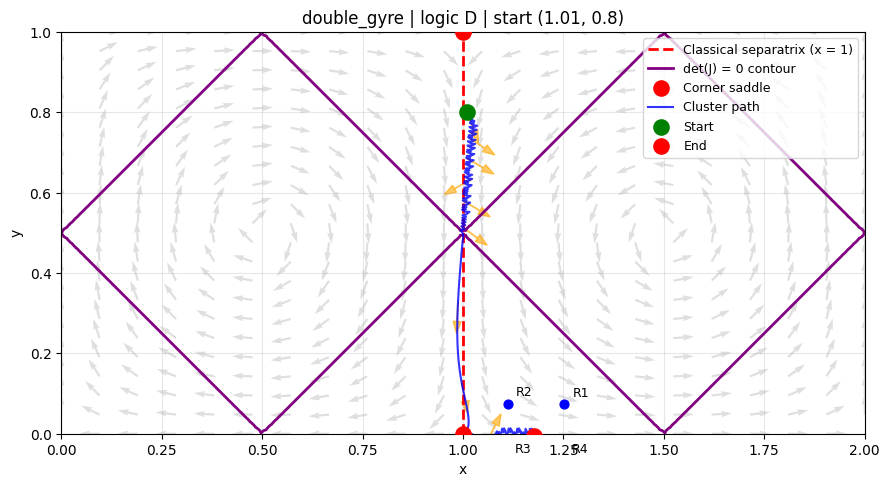

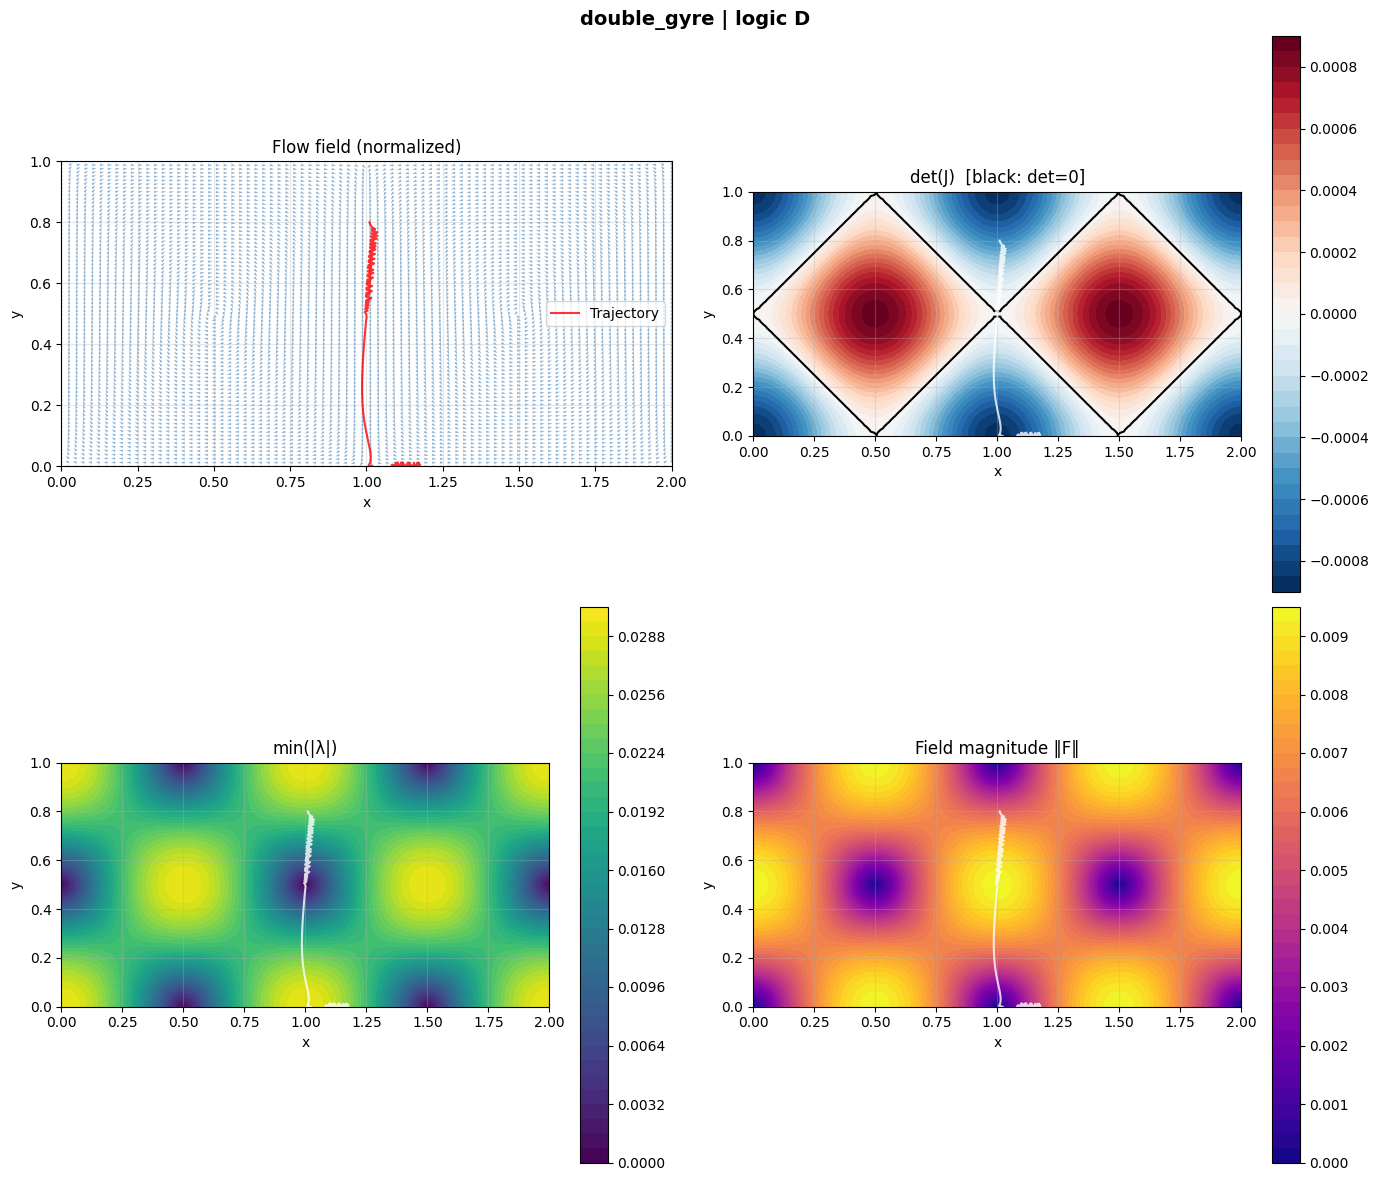

Start:        (+1.010, +0.800)
End:          (+1.177, -0.006)
Path length:  1.990
det(J) end:   -0.0006
trace(J) end: +0.0000


In [203]:
# -------- EDIT THESE --------
field_type   = 'double_gyre'       # 'double_vortex', 'double_saddle', 'double_gyre', 'four_vortex'
logic        = 'D'                 # 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', or 'I'
initial_pos  = (1.01, .8)          # starting centroid

# Simulation parameters (defaults switch with field type)
if field_type == 'double_gyre':
    n_steps           = 200
    step_size         = 0.01
    formation_radius  = 0.1
else:
    n_steps           = 200
    step_size         = 0.02
    formation_radius  = 0.3

rotation_rate     = 0.15
correction_weight = 0.15           # used as blend weight by D/E/F/G/H, correction strength by A/B/C/I
init_mode         = 2              # 2 = square random angle, 1 = square fixed angle
seed              = 42

# Double-gyre parameters (ignored for other fields)
dg_A     = 0.003
dg_eps   = 0.003
dg_omega = 0#2*np.pi/10
dg_t     = 0.003
# ----------------------------

vf = VectorField(field_type=field_type,
                 dg_A=dg_A, dg_eps=dg_eps, dg_omega=dg_omega, dg_t=dg_t)
robots = RobotCluster4(formation_radius=formation_radius,
                       initial_pos=initial_pos,
                       init_mode=init_mode,
                       manual_offset=0.0,
                       seed=seed)

centroid_hist = np.zeros((n_steps, 2))
eigvec_hist = []

# We need grad(det J) for D/E/F — extract it from the cluster before normalisation
# by computing_determinant_gradient which returns the sign-flipped unit vector.
# For D/E/F we want the raw gradient so we can apply our own sign logic; simplest
# way is to recompute it inline using the same 4-choose-3 trick.
from itertools import combinations
def raw_grad_det(robots):
    dets, cents = [], []
    for combo in combinations(range(4), 3):
        pos_s = robots.positions[list(combo)]
        read_s = robots.vector_readings[list(combo)]
        centroid = np.mean(pos_s, axis=0)
        A = np.column_stack([pos_s[:, 0], pos_s[:, 1], np.ones(3)])
        try:
            cu, _, _, s_u = np.linalg.lstsq(A, read_s[:, 0], rcond=None)
            cv, _, _, _   = np.linalg.lstsq(A, read_s[:, 1], rcond=None)
            if len(s_u) > 0 and s_u[-1] > 1e-12:
                if s_u[0] / s_u[-1] > 1e8:
                    continue
            Jk = np.array([[cu[0], cu[1]], [cv[0], cv[1]]])
            dets.append(np.linalg.det(Jk)); cents.append(centroid)
        except np.linalg.LinAlgError:
            continue
    if len(cents) < 4:
        return np.array([0.0, 0.0])
    cents = np.array(cents); dets = np.array(dets)
    Ag = np.column_stack([cents[:, 0], cents[:, 1], np.ones(len(cents))])
    try:
        c, *_ = np.linalg.lstsq(Ag, dets, rcond=None)
        return np.array([c[0], c[1]])
    except np.linalg.LinAlgError:
        return np.array([0.0, 0.0])

for step in range(n_steps):
    centroid_hist[step] = robots.centroid
    robots.update_readings(vf)
    J = robots.compute_jacobian()
    if J is None:
        continue
    det_J = np.linalg.det(J)
    flow = np.mean(robots.vector_readings, axis=0)

    if logic in ('A', 'B', 'C'):
        # Original two-piece controller: primary + orthogonal correction
        correction = robots.compute_determinant_gradient()  # already sign-flipped unit
        if logic == 'A':
            primary = logic_A_flow_aligned(J, flow)
        elif logic == 'B':
            primary = logic_B_most_negative(J, flow)
        else:
            primary = logic_C_blended(J, flow, det_J)
        robots.update_formation_orientation(primary, rotation_rate)
        corr_parallel = np.dot(correction, primary) * primary
        corr_orthog   = correction - corr_parallel
        direction = _normalise(primary + correction_weight * corr_orthog)
        eigvec_hist.append((robots.centroid.copy(), primary.copy()))

    elif logic in ('D', 'E', 'F'):
        # D/E/F return the full step direction (no separate correction step)
        grad_det = raw_grad_det(robots)
        if logic == 'D':
            direction, _ = logic_D_descent_flow(J, flow, det_J, grad_det, correction_weight)
        elif logic == 'E':
            direction, _ = logic_E_descent_eigenvec(J, flow, det_J, grad_det, correction_weight)
        else:
            direction, _ = logic_F_blended_DE(J, flow, det_J, grad_det, correction_weight)
        robots.update_formation_orientation(direction, rotation_rate)
        eigvec_hist.append((robots.centroid.copy(), direction.copy()))

    elif logic in ('G', 'H', 'I'):
            # G/H/I: zero-seeking (sign-flipped) — same interface as D/E/F
            grad_det = raw_grad_det(robots)
            if logic == 'G':
                direction, _ = logic_G_zero_flow(J, flow, det_J, grad_det, correction_weight)
            elif logic == 'H':
                direction, _ = logic_H_zero_eigenvec(J, flow, det_J, grad_det, correction_weight)
            else:
                direction, _ = logic_I_blended_GH(J, flow, det_J, grad_det, correction_weight)
            robots.update_formation_orientation(direction, rotation_rate)
            eigvec_hist.append((robots.centroid.copy(), direction.copy()))

    else:
        raise ValueError(f"Unknown logic: {logic}")

    robots.update_positions(step_size * direction)

title = f"{field_type} | logic {logic} | start {initial_pos}"
_ = plot_trial(centroid_hist, eigvec_hist, robots, vf, title=title)
plt.show()

# Four-panel field analysis
_ = plot_field_analysis(vf, centroid_hist, title=f"{field_type} | logic {logic}")
plt.show()

# Numerical summary
start = centroid_hist[0]; end = centroid_hist[-1]
path_length = np.sum(np.linalg.norm(np.diff(centroid_hist, axis=0), axis=1))
J_end = vf.jacobian_twosided(*end)
print(f"Start:        ({start[0]:+.3f}, {start[1]:+.3f})")
print(f"End:          ({end[0]:+.3f}, {end[1]:+.3f})")
print(f"Path length:  {path_length:.3f}")
print(f"det(J) end:   {np.linalg.det(J_end):+.4f}")
print(f"trace(J) end: {np.trace(J_end):+.4f}")

---

### Optional: det(J) heatmap for the current field

Useful when picking starting positions — shows where det(J) is near zero.

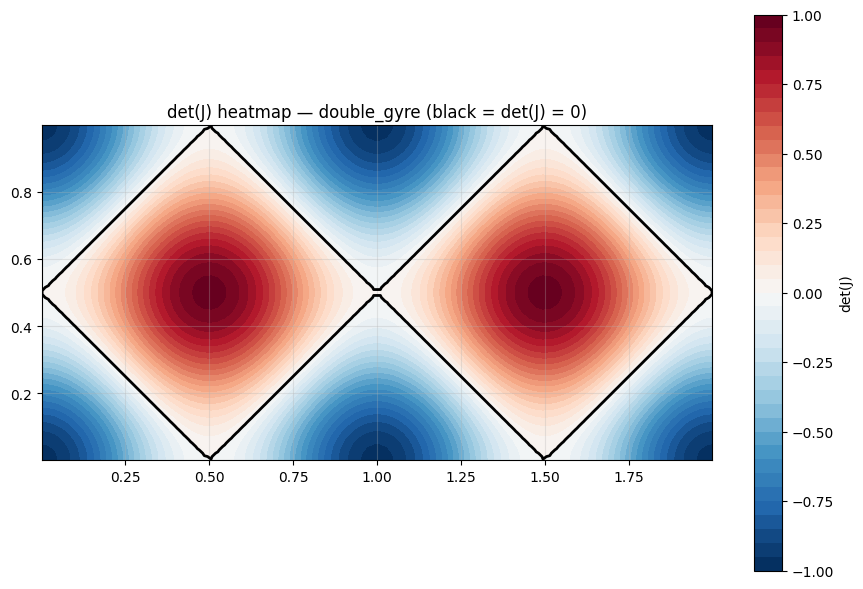

In [202]:
def plot_det_heatmap(field_type='double_vortex', resolution=100,
                     dg_A=0.1, dg_eps=0.0, dg_omega=2*np.pi/10, dg_t=0.0):
    vf = VectorField(field_type=field_type,
                     dg_A=dg_A, dg_eps=dg_eps, dg_omega=dg_omega, dg_t=dg_t)
    if field_type == 'double_vortex':
        xlim, ylim = (-5, 5), (-5, 5)
    elif field_type == 'double_saddle':
        xlim, ylim = (-6, 6), (-6, 6)
    elif field_type == 'double_gyre':
        xlim, ylim = (0.001, 1.999), (0.001, 0.999)
    elif field_type == 'four_vortex':
        xlim, ylim = (-3, 3), (-2, 5)
    else:
        xlim, ylim = (-5, 5), (-5, 5)

    xs = np.linspace(*xlim, resolution)
    ys = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(xs, ys)
    D = np.zeros_like(X)
    for i in range(resolution):
        for j in range(resolution):
            D[i, j] = np.linalg.det(vf.jacobian_twosided(X[i, j], Y[i, j]))

    lim = max(abs(D.min()), abs(D.max()))
    fig, ax = plt.subplots(figsize=(9, 6))
    cs = ax.contourf(X, Y, D, levels=40, cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.contour(X, Y, D, levels=[0], colors='black', linewidths=2)
    plt.colorbar(cs, ax=ax, label='det(J)')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_title(f'det(J) heatmap — {field_type} (black = det(J) = 0)')
    plt.tight_layout()
    return fig


def plot_field_analysis(vf, centroid_hist, resolution=80, title=''):
    """Four-panel analysis: flow field, det(J), min|eigenvalue|, field magnitude."""
    if vf.field_type == 'double_vortex':
        xlim, ylim = (-5, 5), (-5, 5)
    elif vf.field_type == 'double_saddle':
        xlim, ylim = (-6, 6), (-6, 6)
    elif vf.field_type == 'double_gyre':
        xlim, ylim = (0, 2), (0, 1)
    elif vf.field_type == 'four_vortex':
        xlim, ylim = (-3, 3), (-2, 5)
    else:
        xlim, ylim = (-5, 5), (-5, 5)

    xs = np.linspace(*xlim, resolution)
    ys = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(xs, ys)

    # Compute all quantities on same grid
    Det = np.zeros_like(X)
    MinEig = np.zeros_like(X)
    Mag = np.zeros_like(X)
    U = np.zeros_like(X)
    V = np.zeros_like(X)

    for i in range(resolution):
        for j in range(resolution):
            x, y = X[i, j], Y[i, j]
            U[i, j], V[i, j] = vf.evaluate(x, y)
            Mag[i, j] = np.sqrt(U[i, j]**2 + V[i, j]**2)
            J = vf.jacobian_twosided(x, y)
            Det[i, j] = np.linalg.det(J)
            evals = np.linalg.eigvalsh(J)
            MinEig[i, j] = np.min(np.abs(evals))

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Panel 1: Flow field
    ax = axes[0, 0]
    mag_norm = np.sqrt(U**2 + V**2) + 1e-6
    ax.quiver(X, Y, U/mag_norm, V/mag_norm, alpha=0.6, color='steelblue')
    ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'r-', lw=1.5, alpha=0.8, label='Trajectory')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('Flow field (normalized)')
    ax.legend()

    # Panel 2: det(J)
    ax = axes[0, 1]
    lim_det = max(abs(Det.min()), abs(Det.max()))
    cs = ax.contourf(X, Y, Det, levels=40, cmap='RdBu_r', vmin=-lim_det, vmax=lim_det)
    ax.contour(X, Y, Det, levels=[0], colors='black', linewidths=1.5)
    ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'w-', lw=1.5, alpha=0.8)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('det(J)  [black: det=0]')
    plt.colorbar(cs, ax=ax)

    # Panel 3: Smallest eigenvalue magnitude
    ax = axes[1, 0]
    cs = ax.contourf(X, Y, MinEig, levels=40, cmap='viridis')
    ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'w-', lw=1.5, alpha=0.8)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('min(|λ|)')
    plt.colorbar(cs, ax=ax)

    # Panel 4: Field magnitude
    ax = axes[1, 1]
    cs = ax.contourf(X, Y, Mag, levels=40, cmap='plasma')
    ax.plot(centroid_hist[:, 0], centroid_hist[:, 1], 'w-', lw=1.5, alpha=0.8)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('Field magnitude ‖F‖')
    plt.colorbar(cs, ax=ax)

    plt.tight_layout()
    return fig

_ = plot_det_heatmap(field_type='double_gyre')
plt.show()